<a href="https://colab.research.google.com/github/abhishekCS0024/LangGraph/blob/main/Parallel_Workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install langgraph langchain-openai python-dotenv langchain-groq


In [ ]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from pydantic import BaseModel, Field
from dotenv import load_dotenv

In [ ]:
load_dotenv()

False

In [ ]:
from google.colab import userdata
import os
os.environ['GROQ_API_KEY'] = userdata.get('Groq')

In [ ]:

llm = ChatGroq(model="qwen/qwen3-32b")

Project
Input: Code snippet

Evaluation:
Time complexity,
Space complexity,
Readability

Final: overall code

In [ ]:
class EvaluationSchema(BaseModel):
  feedback: str= Field(description='Detailed feedback for the given line of the code')
  score: int = Field(description='Score for the given line of the code out of 10')

In [ ]:
structured_model=llm.with_structured_output(EvaluationSchema)

In [ ]:
code="""
class Solution {
public:
    vector<int> topKFrequent(vector<int>& nums, int k) {
        unordered_map<int,int> freq;
        for(int x : nums) freq[x]++;

        priority_queue<pair<int,int>> pq;
        for(auto &it : freq){
            pq.push({it.second, it.first});
        }

        vector<int> ans;
        while(k--){
            ans.push_back(pq.top().second);
            pq.pop();
        }
        return ans;
    }
};

"""
prompt=f'Evalute the code snippet of the given code and provide the feedback and score out of 10 \n {code}.'

structured_model.invoke(prompt)

EvaluationSchema(feedback='The code correctly uses an unordered_map to count frequencies and a max-heap (priority_queue) to extract the top k elements. However, the time complexity is O(n log n) due to building a heap of all elements, which is suboptimal. A min-heap of size k would reduce the time complexity to O(n log k), making it more efficient for large datasets. The code is correct and handles edge cases implicitly, but optimizing the heap size could improve performance.', score=8)

In [ ]:
import operator
from typing import Annotated

class codeState(TypedDict):
  code: str
  Time_complexity:str
  Space_complexity:str
  Readability:str
  # in order the numerical score of the above state
  individual_scores: Annotated[list[int],operator.add]
  overall_feedback:str
  avg_score:float

In [ ]:
graph=StateGraph(codeState)

In [ ]:
def evaluate_time(state:codeState):
  prompt=f'Evalute the time complexity of the given code and provide the feedback and score out of 10 \n {state["code"]}.'
  output=structured_model.invoke(prompt)
  return {
    "Time_complexity": output.feedback,
    "individual_scores": [output.score]
}

In [ ]:
def evaluate_space(state:codeState):
  prompt=f'Evalute the Space complexity of the given code and provide the feedback and score out of 10 \n {state["code"]}.'
  output=structured_model.invoke(prompt)
  return {
    "Space_complexity": output.feedback,
    "individual_scores": [output.score]
}



In [ ]:
def evaluate_readability(state:codeState):
  prompt=f'Evalute the Readability of the given code and provide the feedback and score out of 10 \n {state["code"]}.'
  output=structured_model.invoke(prompt)
  return {
        "Readability": output.feedback,
        "individual_scores": [output.score]
    }

In [ ]:
def final_evaluation(state:codeState):

    # summary feedback
    prompt = f'Based on the following feedbacks create a summarized feedback \n language feedback - {state["Time_complexity"]} \n depth of analysis feedback - {state["Space_complexity"]} \n clarity of thought feedback - {state["Readability"]}'
    overall_feedback = llm.invoke(prompt).content

    # avg calculate
    avg_score = sum(state['individual_scores']) / len(state['individual_scores'])


    return {'overall_feedback': overall_feedback, 'avg_score': avg_score}

In [ ]:
graph.add_node('evaluate_time',evaluate_time)
graph.add_node('evaluate_space',evaluate_space)
graph.add_node('evaluate_readability',evaluate_readability)
graph.add_node('final_evaluation',final_evaluation)

In [ ]:
# edges
graph.add_edge(START, 'evaluate_time')
graph.add_edge(START, 'evaluate_space')
graph.add_edge(START, 'evaluate_readability')

graph.add_edge('evaluate_time', 'final_evaluation')
graph.add_edge('evaluate_space', 'final_evaluation')
graph.add_edge('evaluate_readability', 'final_evaluation')

graph.add_edge('final_evaluation', END)

workflow = graph.compile()

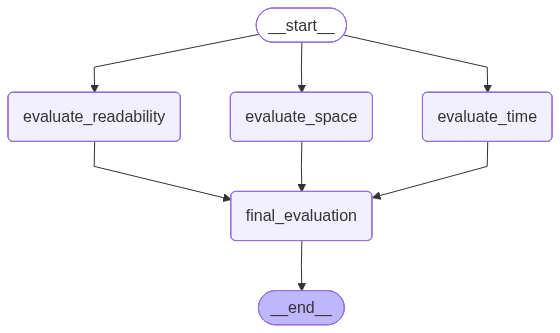

In [ ]:
workflow

In [ ]:
intial_state = {
    'code': code
}

workflow.invoke(intial_state)

{'code': '\nclass Solution {\npublic:\n    vector<int> topKFrequent(vector<int>& nums, int k) {\n        unordered_map<int,int> freq;\n        for(int x : nums) freq[x]++;\n\n        priority_queue<pair<int,int>> pq;\n        for(auto &it : freq){\n            pq.push({it.second, it.first});\n        }\n\n        vector<int> ans;\n        while(k--){\n            ans.push_back(pq.top().second);\n            pq.pop();\n        }\n        return ans;\n    }\n};\n\n',
 'Time_complexity': 'The code correctly uses a max-heap to find the top k frequent elements, but the time complexity is O(n log n) due to heap operations on all elements. An optimal solution would use a min-heap of size k, reducing the time complexity to O(n log k).',
 'Space_complexity': 'The space complexity of the code is O(n), where n is the number of elements in the input array. This is due to the use of an unordered_map (O(n)) and a priority queue (O(n)) to store frequencies and elements. The auxiliary space (excluding